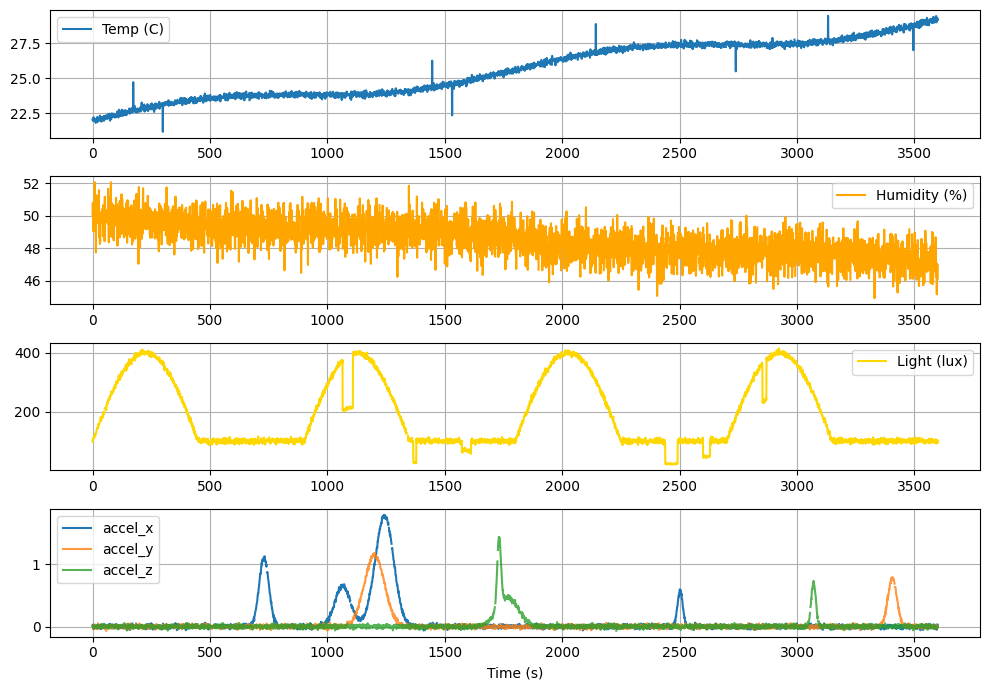

In [1]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID.# Synthetic sensor data for lab3: temperature, humidity, light, 3-axis accel
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.
import numpy as np
import matplotlib.pyplot as plt
 
rng = np.random.default_rng(seed=7083)  # replace with YOUR last 4 digits
np.random.seed(42)                     # reproducible results
fs = 1                                  # 1 Hz sampling
duration_s = 3600                       # one hour
t = np.arange(0, duration_s, 1/fs)
 
 # Temperature: slow diurnal-ish variation + linear drift + Gaussian noise + occasional spikes
temp_base = 22.0
temp = temp_base + 0.6*np.sin(2*np.pi*t/1800)       # 30-min sinusoid
temp += 0.002 * t                                    # small linear drift
temp += np.random.normal(0, 0.12, size=t.shape)     # sensor noise
# inject occasional spikes
spike_idx = np.random.choice(len(t), size=8, replace=False)
temp[spike_idx] += np.random.choice([2.0, -2.0], size=spike_idx.size)
 
# Humidity: loosely anti-correlated with temp + noise
hum = 50.0 - 0.4*(temp - temp_base) + np.random.normal(0, 0.8, size=t.shape)
hum = np.clip(hum, 0, 100)
 
# Light: periodic with brighter daytime pulses + short clouds (dropouts)
light = 100 + 300*np.clip(np.sin(2*np.pi*(t/900)), 0, 1)  # pulsed every 15 minutes
light += np.random.normal(0, 5, size=t.shape)
# cloud events: multiply by factor <1 for short windows
for _ in range(6):
    start = np.random.randint(0, len(t)-60)
    light[start:start+np.random.randint(10,60)] *= np.random.uniform(0.2, 0.7)
 
# 3-axis accelerometer: quiet with occasional motion bursts (Gaussian bumps)
accel = np.random.normal(0, 0.02, size=(3, len(t)))
for _ in range(10):
    center = np.random.randint(0, len(t))
    width = np.random.randint(5, 50)
    amp = np.random.uniform(0.3, 1.2)
    bump = amp * np.exp(-0.5 * ((np.arange(len(t)) - center)/width)**2)
    axis = np.random.choice(3)
    accel[axis] += bump
 
# Simulate missing data (dropouts) ~2% per sensor
for arr in (temp, hum, light):
    mask = np.random.rand(len(t)) < 0.02
    arr[mask] = np.nan
# for accelerometer, drop whole sample rows occasionally
drop_rows = np.random.rand(len(t)) < 0.01
accel[:, drop_rows] = np.nan
 
# Pack into a dict for convenience
data = {
    't': t,
    'temperature_C': temp,
    'humidity_pct': hum,
    'light_lux': light,
    'accel_x_g': accel[0],
    'accel_y_g': accel[1],
    'accel_z_g': accel[2],
}
 
# Quick plots
plt.figure(figsize=(10,7))
ax1 = plt.subplot(4,1,1); plt.plot(t, temp, label='Temp (C)'); plt.legend(); 
plt.grid(True)
ax2 = plt.subplot(4,1,2, sharex=ax1); plt.plot(t, hum, color='orange', 
label='Humidity (%)'); plt.legend(); plt.grid(True)
ax3 = plt.subplot(4,1,3, sharex=ax1); plt.plot(t, light, color='gold', label='Light (lux)'); plt.legend(); plt.grid(True)
ax4 = plt.subplot(4,1,4, sharex=ax1); plt.plot(t, accel[0], label='accel_x'); 
plt.plot(t, accel[1], label='accel_y', alpha=0.8)
plt.plot(t, accel[2], label='accel_z', alpha=0.8); plt.legend(); plt.grid(True)
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


In [2]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

In [3]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.


In [4]:
# Embedded box plot image

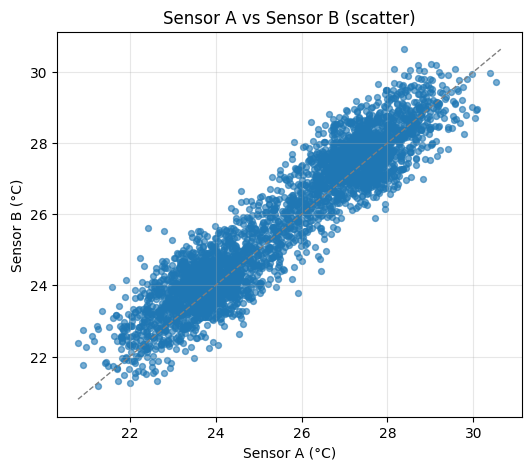

In [5]:

import numpy as np
import matplotlib.pyplot as plt
# prepare sensor arrays
try:
    sensor_a
    sensor_b
except NameError:
    try:
        temp
        sensor_a = temp + np.random.normal(0,0.5,size=temp.shape)
        sensor_b = temp + np.random.normal(0,0.5,size=temp.shape) + 0.2
    except NameError:
        rng = np.random.default_rng(0)
        sensor_a = rng.normal(22, 0.5, size=200)
        sensor_b = rng.normal(22.2, 0.6, size=200)

# clean NaNs
def fill_nan_by_interp(arr):
    arr = np.array(arr, dtype=float)
    nans = np.isnan(arr)
    if nans.all():
        return np.zeros_like(arr) + 22.0
    idx = np.arange(arr.size)
    good = ~nans
    if good.sum() == 0:
        return arr
    arr[nans] = np.interp(idx[nans], idx[good], arr[good])
    return arr

sensor_a = fill_nan_by_interp(sensor_a)
sensor_b = fill_nan_by_interp(sensor_b)

plt.figure(figsize=(6,5))
plt.scatter(sensor_a, sensor_b, alpha=0.6, s=18)
minv = min(np.min(sensor_a), np.min(sensor_b))
maxv = max(np.max(sensor_a), np.max(sensor_b))
plt.plot([minv, maxv], [minv, maxv], color='gray', linestyle='--', linewidth=1)
plt.xlabel('Sensor A (°C)')
plt.ylabel('Sensor B (°C)')
plt.title('Sensor A vs Sensor B (scatter)')
plt.grid(alpha=0.3)
plt.show()


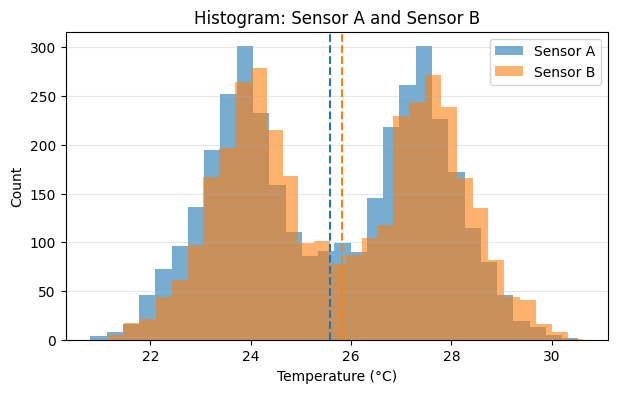

In [6]:

import numpy as np
import matplotlib.pyplot as plt
# prepare sensor arrays
try:
    sensor_a
    sensor_b
except NameError:
    try:
        temp
        sensor_a = temp + np.random.normal(0,0.5,size=temp.shape)
        sensor_b = temp + np.random.normal(0,0.5,size=temp.shape) + 0.2
    except NameError:
        rng = np.random.default_rng(0)
        sensor_a = rng.normal(22, 0.5, size=200)
        sensor_b = rng.normal(22.2, 0.6, size=200)

# clean NaNs
import numpy as _np

def fill_nan_by_interp(arr):
    arr = _np.array(arr, dtype=float)
    nans = _np.isnan(arr)
    if nans.all():
        return _np.zeros_like(arr) + 22.0
    idx = _np.arange(arr.size)
    good = ~nans
    if good.sum() == 0:
        return arr
    arr[nans] = _np.interp(idx[nans], idx[good], arr[good])
    return arr

sensor_a = fill_nan_by_interp(sensor_a)
sensor_b = fill_nan_by_interp(sensor_b)

plt.figure(figsize=(7,4))
bins = 30
plt.hist(sensor_a, bins=bins, alpha=0.6, label='Sensor A')
plt.hist(sensor_b, bins=bins, alpha=0.6, label='Sensor B')
# mean lines
plt.axvline(sensor_a.mean(), color='tab:blue', linestyle='--')
plt.axvline(sensor_b.mean(), color='tab:orange', linestyle='--')
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram: Sensor A and Sensor B')
plt.grid(axis='y', alpha=0.3)
plt.show()


C:\Users\jsria\AppData\Local\Temp\ipykernel_40188\1988901590.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sensor_a_clean, sensor_b_clean], labels=['Sensor A','Sensor B'], patch_artist=True,


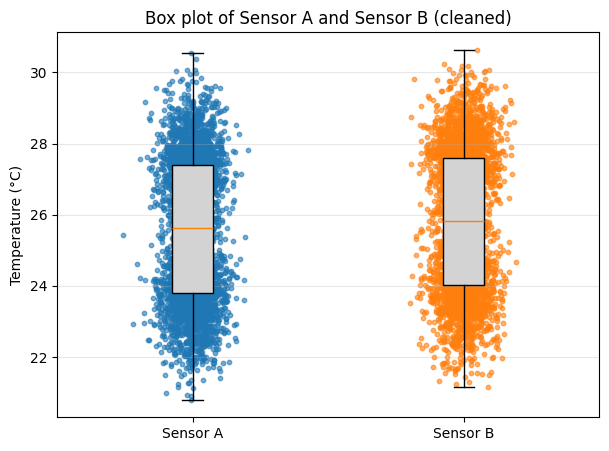

In [7]:

import numpy as np
import matplotlib.pyplot as plt
# prepare sensor arrays
try:
    sensor_a
    sensor_b
except NameError:
    try:
        temp
        sensor_a = temp + np.random.normal(0,0.5,size=temp.shape)
        sensor_b = temp + np.random.normal(0,0.5,size=temp.shape) + 0.2
    except NameError:
        rng = np.random.default_rng(0)
        sensor_a = rng.normal(22, 0.5, size=200)
        sensor_b = rng.normal(22.2, 0.6, size=200)

# clean NaNs
def fill_nan_by_interp(arr):
    arr = np.array(arr, dtype=float)
    nans = np.isnan(arr)
    if nans.all():
        return np.zeros_like(arr) + 22.0
    idx = np.arange(arr.size)
    good = ~nans
    if good.sum() == 0:
        return arr
    arr[nans] = np.interp(idx[nans], idx[good], arr[good])
    return arr

sensor_a_clean = fill_nan_by_interp(sensor_a)
sensor_b_clean = fill_nan_by_interp(sensor_b)

plt.figure(figsize=(7,5))
plt.boxplot([sensor_a_clean, sensor_b_clean], labels=['Sensor A','Sensor B'], patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='k'))
# jittered points
xa = np.random.normal(1, 0.06, size=sensor_a_clean.size)
xb = np.random.normal(2, 0.06, size=sensor_b_clean.size)
plt.scatter(xa, sensor_a_clean, alpha=0.6, color='tab:blue', s=10)
plt.scatter(xb, sensor_b_clean, alpha=0.6, color='tab:orange', s=10)
plt.ylabel('Temperature (°C)')
plt.title('Box plot of Sensor A and Sensor B (cleaned)')
plt.grid(axis='y', alpha=0.3)
plt.show()
